# Week 12 - Natural Language Processing (NLP)

## **Assignment**: End-to-End Named Entity Recognition (NER) for Customer Support Ticket AnalysisOverview

Companies receive thousands of customer support tickets every day. Automatically identifying key entities such as customer names, organizations, products, locations, dates, and monetary values helps route tickets faster, automate CRM updates, and improve response times.
In this assignment, you will build an end-to-end **Named Entity Recognition (NER)** pipeline, starting from text preprocessing and exploratory analysis to training and evaluating an NER model.

## Dataset
**Primary Dataset:** CoNLL-2003 Named Entity Recognition Dataset

**Optional Dataset:** WNUT-17 Emerging Entities Dataset

In [ ]:
import kagglehub
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter

import nltk
nltk.download("averaged_perceptron_tagger_eng")
from nltk import pos_tag

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [ ]:
# Download latest version
path = kagglehub.dataset_download("juliangarratt/conll2003-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'conll2003-dataset' dataset.
Path to dataset files: /kaggle/input/conll2003-dataset


In [ ]:
def read_conll_file(filepath):
  """
  Reads a CoNLL-format file and returns a list of sentences,
  where each sentence is a list of (word, ner_tag) tuples.
  """
  sentences = []
  current_sentence = []
  with open(filepath, "r", encoding="utf-8") as f:
    for line in f:
      line = line.strip()
      if line == "" or line.startswith("-DOCSTART-"): # blank line = end of sentence
        if current_sentence:
          sentences.append(current_sentence)
          current_sentence = []
        continue
      parts = line.split()
      current_sentence.append((parts[0], parts[-1])) # line's first column is word and last column is NER tag

  if current_sentence:  # catch last sentence if file doesn't end in blank line
    sentences.append(current_sentence)
  return sentences

## Core Tasks

### Task 1: Text Preprocessing

#### Prepare the dataset for NER.
- Tokenize the text.
- Inspect entity labels.
- Analyze sentence length and entity distribution.

In [ ]:
train_path = os.path.join(path, "conll2003", "eng.train")
valid_path = os.path.join(path, "conll2003", "eng.testa")
test_path = os.path.join(path, "conll2003", "eng.testb")

In [ ]:
train_sentences = read_conll_file(train_path)
valid_sentences = read_conll_file(valid_path)
test_sentences  = read_conll_file(test_path)

# peek at the first sentence
for word, tag in train_sentences[0]:
    print(f"{word:15s} {tag}")

EU              B-ORG
rejects         O
German          B-MISC
call            O
to              O
boycott         O
British         B-MISC
lamb            O
.               O


In [ ]:
print("Train sentences:", len(train_sentences))
print("Valid sentences:", len(valid_sentences))
print("Test sentences:", len(test_sentences))

Train sentences: 14041
Valid sentences: 3250
Test sentences: 3453


In [ ]:
train_tokens = []
tag_counter = Counter()
sentence_lengths = []
for sentence in train_sentences:
  sentence_lengths.append(len(sentence))
  for word, tag in sentence:
    train_tokens.append(word)
    tag_counter[tag] += 1

print("Unique NER tags in dataset:", sorted(tag_counter.keys()))

Unique NER tags in dataset: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']


In [ ]:
print("Min sentence length:", min(sentence_lengths))
print("Max sentence length:", max(sentence_lengths))
print("Avg sentence length: %.2f" % (sum(sentence_lengths) / len(sentence_lengths)))

Min sentence length: 1
Max sentence length: 113
Avg sentence length: 14.50


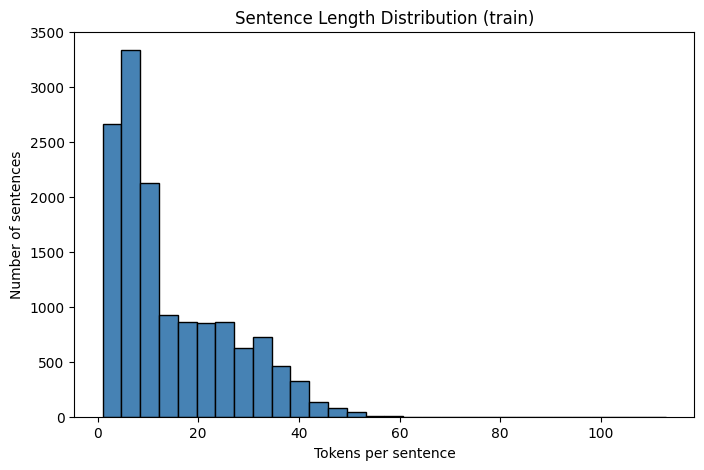

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(sentence_lengths, bins=30, color="steelblue", edgecolor="black")
plt.title("Sentence Length Distribution (train)")
plt.xlabel("Tokens per sentence")
plt.ylabel("Number of sentences")
plt.show()

In [ ]:
train_vocab = set(train_tokens)
print("Total tokens (all splits):", len(train_tokens))
print("Vocabulary size (unique tokens):", len(train_vocab))

Total tokens (all splits): 203621
Vocabulary size (unique tokens): 23623


In [ ]:
entity_type_counter = Counter()
for tag, count in tag_counter.items():
    if tag == "O":
        entity_type_counter["O (non-entity)"] += count
    else:
        entity_type = tag.split("-")[1]   # "B-PER" -> "PER"
        entity_type_counter[entity_type] += count

print("Entity type frequency:")
for etype, count in entity_type_counter.most_common():
    print(f"{etype:15s}: {count}")

Entity type frequency:
O (non-entity) : 169578
PER            : 11128
ORG            : 10025
LOC            : 8297
MISC           : 4593


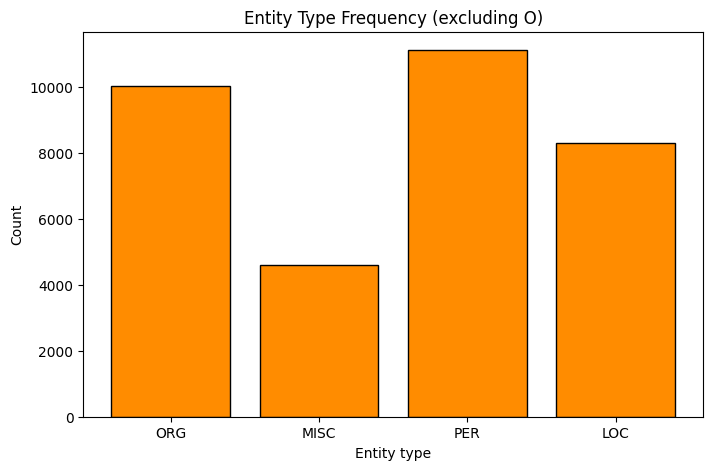

In [ ]:
plt.figure(figsize=(8,5))
types_no_o = {k: v for k, v in entity_type_counter.items() if k != "O (non-entity)"}
plt.bar(types_no_o.keys(), types_no_o.values(), color="darkorange", edgecolor="black")
plt.title("Entity Type Frequency (excluding O)")
plt.xlabel("Entity type")
plt.ylabel("Count")
plt.show()

In [ ]:
valid_tokens = set(w for sentence in valid_sentences for w, t in sentence)
test_tokens  = set(w for sentence in test_sentences  for w, t in sentence)

unseen_in_valid = valid_tokens - train_vocab
unseen_in_test  = test_tokens - train_vocab

print("Words in validation not seen in train:", len(unseen_in_valid))
print("Words in test not seen in train:", len(unseen_in_test))

Words in validation not seen in train: 3260
Words in test not seen in train: 3693


#### Deliverable: Report the number of sentences, vocabulary size, and frequency of each entity type.



In [ ]:
summary_df = pd.DataFrame({
    "Metric": ["Train sentences", "Validation sentences", "Test sentences",
               "Total tokens", "Vocabulary size",
               "Min sentence length", "Max sentence length", "Avg sentence length", "Words in validation not seen in train", "Words in test not seen in train"],
    "Value": [len(train_sentences), len(valid_sentences), len(test_sentences),
              len(train_tokens), len(train_vocab),
              min(sentence_lengths), max(sentence_lengths),
              round(sum(sentence_lengths) / len(sentence_lengths), 2), len(unseen_in_valid), len(unseen_in_test)]
})
display(summary_df)

entity_freq_df = pd.DataFrame(entity_type_counter.most_common(), columns=["Entity Type", "Count"])
display(entity_freq_df)

,Metric,Value
0,Train sentences,14041.0
1,Validation sentences,3250.0
2,Test sentences,3453.0
3,Total tokens,203621.0
4,Vocabulary size,23623.0
5,Min sentence length,1.0
6,Max sentence length,113.0
7,Avg sentence length,14.5
8,Words in validation not seen in train,3260.0
9,Words in test not seen in train,3693.0


,Entity Type,Count
0,O (non-entity),169578
1,PER,11128
2,ORG,10025
3,LOC,8297
4,MISC,4593


The CoNLL-2003 dataset consists of 14,041 training sentences, 3,250 validation sentences, and 3,453 test sentences. It has 203,621 tokens in training set with a vocabulary of 23,623 unique words. Notably, 3,260 words in the validation set and 3,693 words in the test set never appear in the training vocabulary, highlighting the out-of-vocabulary challenge any model must generalize past. Sentence length ranges from 1 to 113 tokens with an average of 14.5 tokens per sentence. Among entity types, PER (person, 11,128) is the most frequent, followed by ORG (10,025), LOC (8,297), and MISC (4,593), while the non-entity "O" tag dominates overall at 169,578 occurrences, since most words in any sentence are not named entities.

### Task 2: Feature Engineering
#### Generate features for sequence labeling.
- Create word-level features (lowercase, prefixes/suffixes, capitalization).
- Optionally include POS tags or word embeddings.


In [ ]:
def word_features(word):
    """
    Extracts a dictionary of hand-crafted features for a single word.
    These are the kinds of features classic NER models (like CRFs) use.
    """
    return {
        "word": word,
        "word_lower": word.lower(),
        "prefix_1": word[:1],
        "prefix_2": word[:2],
        "prefix_3": word[:3],
        "suffix_1": word[-1:],
        "suffix_2": word[-2:],
        "suffix_3": word[-3:],
        "is_capitalized": word[0].isupper() if len(word) >0 else False,
        "is_all_caps": word.isupper(),
        "is_all_lower": word.islower(),
        "is_numeric": word.isdigit(),
        "has_hypen": "-" in word,
        "word_length": len(word)
    }


In [ ]:
print(word_features("Washington"))
print(word_features("IBM"))
print(word_features("2024"))

{'word': 'Washington', 'word_lower': 'washington', 'prefix_1': 'W', 'prefix_2': 'Wa', 'prefix_3': 'Was', 'suffix_1': 'n', 'suffix_2': 'on', 'suffix_3': 'ton', 'is_capitalized': True, 'is_all_caps': False, 'is_all_lower': False, 'is_numeric': False, 'has_hypen': False, 'word_length': 10}
{'word': 'IBM', 'word_lower': 'ibm', 'prefix_1': 'I', 'prefix_2': 'IB', 'prefix_3': 'IBM', 'suffix_1': 'M', 'suffix_2': 'BM', 'suffix_3': 'IBM', 'is_capitalized': True, 'is_all_caps': True, 'is_all_lower': False, 'is_numeric': False, 'has_hypen': False, 'word_length': 3}
{'word': '2024', 'word_lower': '2024', 'prefix_1': '2', 'prefix_2': '20', 'prefix_3': '202', 'suffix_1': '4', 'suffix_2': '24', 'suffix_3': '024', 'is_capitalized': False, 'is_all_caps': False, 'is_all_lower': False, 'is_numeric': True, 'has_hypen': False, 'word_length': 4}


In [ ]:
def sentence_to_features(sentence):
    """
    sentence: list of (word, tag) tuples
    Returns: list of feature dictionaries, one per word, including
             context from the previous and next word.
    """
    words = [w for w, t in sentence]
    pos_tags = [tag for word, tag in pos_tag(words)]
    features_list = []
    for i, word in enumerate(words):
      features = word_features(word)
      features["pos_tag"] = pos_tags[i]

      if i>0:
        prev_word = words[i-1]
        features["prev_word_lower"] = prev_word.lower()
        features["prev_is_capitalized"] = prev_word[0].isupper()
        features["prev_pos_tag"] = pos_tags[i - 1]
      else:
        features["BOS"] = True

      if i < len(words) - 1:
        next_word = words[i+1]
        features["next_word_lower"] = next_word.lower()
        features["next_is_capitalized"] = next_word[0].isupper()
        features["next_pos_tag"] = pos_tags[i + 1]
      else:
        features["EOS"] = True


      features_list.append(features)
    return features_list

In [ ]:
sample_features = sentence_to_features(train_sentences[0])
print(sample_features[0])   # features for the first word

{'word': 'EU', 'word_lower': 'eu', 'prefix_1': 'E', 'prefix_2': 'EU', 'prefix_3': 'EU', 'suffix_1': 'U', 'suffix_2': 'EU', 'suffix_3': 'EU', 'is_capitalized': True, 'is_all_caps': True, 'is_all_lower': False, 'is_numeric': False, 'has_hypen': False, 'word_length': 2, 'pos_tag': 'NNP', 'BOS': True, 'next_word_lower': 'rejects', 'next_is_capitalized': False, 'next_pos_tag': 'VBZ'}


In [ ]:
X_train = [sentence_to_features(sentence) for sentence in train_sentences]
y_train = [[tag for word, tag in sentence] for sentence in train_sentences]

X_valid = [sentence_to_features(sentence) for sentence in valid_sentences]
y_valid = [[tag for word, tag in sentence] for sentence in valid_sentences]

X_test = [sentence_to_features(sentence) for sentence in test_sentences]
y_test = [[tag for word, tag in sentence] for sentence in test_sentences]


print("Number of feature sets:", len(X_train))
print("Example feature set (first word of first sentence):")
print(X_train[0][0])
print("Corresponding label:", y_train[0][0])

Number of feature sets: 14041
Example feature set (first word of first sentence):
{'word': 'EU', 'word_lower': 'eu', 'prefix_1': 'E', 'prefix_2': 'EU', 'prefix_3': 'EU', 'suffix_1': 'U', 'suffix_2': 'EU', 'suffix_3': 'EU', 'is_capitalized': True, 'is_all_caps': True, 'is_all_lower': False, 'is_numeric': False, 'has_hypen': False, 'word_length': 2, 'pos_tag': 'NNP', 'BOS': True, 'next_word_lower': 'rejects', 'next_is_capitalized': False, 'next_pos_tag': 'VBZ'}
Corresponding label: B-ORG


#### Deliverable: Briefly explain the selected features and why they are useful for NER.



We engineered word-level orthographic features that capture the surface patterns most predictive of named entities in English text. Capitalization features (`is_capitalized`, `is_all_caps`) exploit the convention that proper nouns are capitalized (e.g. organizations like "IBM" are fully capitalized). Prefix and suffix features (1-3 characters) capture morphological patterns common in place names (e.g. "-ton", "-burg") and help distinguish entity subtypes. The lowercase form normalizes casing so the model can generalize spelling regardless of position in a sentence. We also included context features; the previous and next word's lowercase form and capitalization, since entity boundaries often depend on neighboring tokens (e.g. "New York" is a single two-word location). Finally, we included POS tags, since proper nouns (`NNP`) strongly correlate with named entities, giving the model an additional independent signal beyond surface form.

### Task 3: Named Entity Recognition
#### Train an NER model.
Implement either:
- Conditional Random Field (CRF), or
- BiLSTM

In [ ]:
import sklearn_crfsuite

crf = sklearn_crfsuite.CRF(
    algorithm = "lbfgs",
    c1 = 0.1,
    c2 = 0.2,
    max_iterations = 100,
    all_possible_transitions = True
)

crf.fit(X_train, y_train)

CRF(algorithm='lbfgs', all_possible_transitions=True, c1=0.1, c2=0.2,
    max_iterations=100)

In [ ]:
y_pred = crf.predict(X_test)

words = [w for w, t in test_sentences[0]]
for word, true_tag, pred_tag in zip(words, y_test[0], y_pred[0]):
    print(f"{word:15s} true={true_tag:10s} pred={pred_tag}")

SOCCER          true=O          pred=O
-               true=O          pred=O
JAPAN           true=B-LOC      pred=B-PER
GET             true=O          pred=O
LUCKY           true=O          pred=O
WIN             true=O          pred=O
,               true=O          pred=O
CHINA           true=B-PER      pred=B-LOC
IN              true=O          pred=O
SURPRISE        true=O          pred=O
DEFEAT          true=O          pred=O
.               true=O          pred=O


#### Deliverable:
- Precision
- Recall
- F1-score
- Entity-wise performance

In [ ]:
from seqeval.metrics import classification_report, precision_score, recall_score, f1_score

print("Overall Precision:", precision_score(y_test, y_pred))
print("Overall Recall:", recall_score(y_test, y_pred))
print("Overall F1-score:", f1_score(y_test, y_pred))

print("\nEntity-wise performance:")
print(classification_report(y_test, y_pred))

Overall Precision: 0.8150413817920115
Overall Recall: 0.8020538243626062
Overall F1-score: 0.8084954488666785

Entity-wise performance:
              precision    recall  f1-score   support

         LOC       0.84      0.87      0.85      1668
        MISC       0.76      0.76      0.76       702
         ORG       0.78      0.70      0.74      1661
         PER       0.85      0.86      0.85      1617

   micro avg       0.82      0.80      0.81      5648
   macro avg       0.81      0.80      0.80      5648
weighted avg       0.81      0.80      0.81      5648



The CRF model achieved an overall precision of 0.815, recall of 0.802, and F1-score of 0.808 on the CoNLL-2003 test set. Entity-wise, PER (F1 0.85) and LOC (F1 0.85) were recognized most reliably, while ORG scored lowest (F1 0.74) and MISC scored 0.76.

#### Discuss which entity types are most difficult to recognize and why.

**ORG (organization)** was the hardest entity type to recognize, with the lowest F1-score (0.74) and notably lower recall (0.70) than precision (0.78). This is because organization names are highly varied in structure. They can be single words, multi-word phrases, or contain embedded place names (e.g. a sports team named after a city), making them harder to distinguish from **LOC** using surface features like capitalization alone.

### Task 4: Error Analysis
#### Evaluate model predictions.
- Display sample predictions.
- Compare predicted vs. true entities.
- Identify common error patterns.

In [ ]:
def display_sentence_predictions(sentence, true_tags, pred_tags, n=20):
    """Prints a word-by-word comparison of true vs predicted tags."""
    words = [w for w, t in sentence]
    print(f"{'WORD':15s} {'TRUE':10s} {'PRED':10s} {'MATCH'}")
    print("-" * 45)
    for word, true_tag, pred_tag in zip(words[:n], true_tags[:n], pred_tags[:n]):
        match = "✓" if true_tag == pred_tag else "✗ MISMATCH"
        print(f"{word:15s} {true_tag:10s} {pred_tag:10s} {match}")


idx = 10
display_sentence_predictions(test_sentences[idx], y_test[idx], y_pred[idx])

WORD            TRUE       PRED       MATCH
---------------------------------------------
Takuya          B-PER      B-PER      ✓
Takagi          I-PER      I-PER      ✓
scored          O          O          ✓
the             O          O          ✓
winner          O          O          ✓
in              O          O          ✓
the             O          O          ✓
88th            O          O          ✓
minute          O          O          ✓
,               O          O          ✓
rising          O          O          ✓
to              O          O          ✓
head            O          O          ✓
a               O          O          ✓
Hiroshige       B-PER      B-ORG      ✗ MISMATCH
Yanagimoto      I-PER      I-ORG      ✗ MISMATCH
cross           O          O          ✓
towards         O          O          ✓
the             O          O          ✓
Syrian          B-MISC     B-MISC     ✓


In [ ]:
error_sentence_indices = []
for i, (true_seq, pred_seq) in enumerate(zip(y_test, y_pred)):
  if true_seq != pred_seq:
    error_sentence_indices.append(i)

print(f"{len(error_sentence_indices)} out of {len(y_test)} sentences contain at least one error.")

# Show a few sentences that actually contain mistakes
for idx in error_sentence_indices[:5]:
  print(f"\n--- Sentence {idx} ---")
  display_sentence_predictions(test_sentences[idx], y_test[idx], y_pred[idx])

963 out of 3453 sentences contain at least one error.

--- Sentence 0 ---
WORD            TRUE       PRED       MATCH
---------------------------------------------
SOCCER          O          O          ✓
-               O          O          ✓
JAPAN           B-LOC      B-PER      ✗ MISMATCH
GET             O          O          ✓
LUCKY           O          O          ✓
WIN             O          O          ✓
,               O          O          ✓
CHINA           B-PER      B-LOC      ✗ MISMATCH
IN              O          O          ✓
SURPRISE        O          O          ✓
DEFEAT          O          O          ✓
.               O          O          ✓

--- Sentence 5 ---
WORD            TRUE       PRED       MATCH
---------------------------------------------
China           B-LOC      B-LOC      ✓
controlled      O          O          ✓
most            O          O          ✓
of              O          O          ✓
the             O          O          ✓
match           O          O

In [ ]:
confusion_pairs = Counter()
missed_entities = 0      # true tag is an entity, predicted O
spurious_entities = 0    # true tag is O, predicted an entity
type_confusion = 0       # both are entities, both B- (same position), but different type

for true_seq, pred_seq in zip(y_test, y_pred):
  for true_tag, pred_tag in zip(true_seq, pred_seq):
    if true_tag != pred_tag:
      confusion_pairs[(true_tag, pred_tag)] += 1

      if true_tag == "O" and pred_tag != "O":
        spurious_entities += 1
      elif true_tag != "O" and pred_tag == "O":
        missed_entities += 1
      else:
        type_confusion += 1

print("Most common confusions (true_tag -> predicted_tag):")
for (true_tag, pred_tag), count in confusion_pairs.most_common(15):
  print(f"  {true_tag:10s} -> {pred_tag:10s} : {count} times")

Most common confusions (true_tag -> predicted_tag):
  B-ORG      -> B-LOC      : 150 times
  B-ORG      -> B-PER      : 116 times
  O          -> I-ORG      : 115 times
  B-ORG      -> O          : 106 times
  B-LOC      -> B-ORG      : 74 times
  O          -> B-ORG      : 72 times
  B-PER      -> B-ORG      : 69 times
  I-ORG      -> I-PER      : 66 times
  B-PER      -> O          : 62 times
  O          -> I-MISC     : 61 times
  I-ORG      -> O          : 58 times
  B-PER      -> B-LOC      : 54 times
  O          -> B-PER      : 52 times
  B-ORG      -> B-MISC     : 51 times
  B-MISC     -> O          : 48 times


In [ ]:
print("Missed entities (false negatives):", missed_entities)
print("Spurious entities (false positives):", spurious_entities)
print("Type/boundary confusion (entity vs different entity):", type_confusion)

Missed entities (false negatives): 361
Spurious entities (false positives): 411
Type/boundary confusion (entity vs different entity): 1044


#### Deliverable: Summarize the three most frequent types of errors.



The three most frequent error types observed were:

1. **Type confusion between ORG and LOC** : The single largest confusion pair was `B-ORG --> B-LOC` (150 instances), followed by the reverse `B-LOC --> B-ORG` (74 instances). This reflects genuine ambiguity in the text itself, since many organization names (sports teams, national bodies) are built from location names.

2. **Confusion between ORG and PER** : `B-ORG --> B-PER` (116 instances) and `B-PER --> B-ORG` (69 instances) were also common, likely because both categories can be capitalized multi-word proper nouns with similar surface patterns, and the model's features can't always distinguish an organization name from a person's name without stronger semantic context.

3. M**issed and spurious entities around ORG** : `B-ORG --> O` (106, missed) and `O --> B-ORG` (72, spurious) show the model both under- and over-detects organizations, suggesting the ORG category has the least consistent surface signal of the four entity types, consistent with its lowest F1-score.

### Task 5: Business Impact
#### Assume the model will be deployed in a customer support system.
Discuss:
- How NER can automate ticket routing.
- How extracted entities improve customer service.
- Limitations of the current system and possible improvements.

1. **How NER can automate ticket routing**

Extracted entities let a ticket be routed algorithmically instead of manually. An `ORG` entity (a partner, vendor, or product-line name) can send a ticket straight to the team that owns that account. A `LOC` entity can route it to the correct region-specific support queue, which matters for time zones, languages, and local SLAs. A `PER` entity lets the system auto-match the ticket to an existing customer record in the CRM, instead of an agent manually searching for it. In short, entities give a routing engine the structured signals it needs to make a decision the moment a ticket arrives, rather than waiting for a human to read and triage it first.

2. **How extracted entities improve customer service**

- **Faster response times** : entities pre-fill ticket metadata (customer, product, location), so agents start with context instead of hunting for it.

- **Automated CRM updates** : recognized customer/organization names can auto-link or update CRM records, cutting manual data entry and its errors.

- **Personalization** : responses can reference the specific product or issue mentioned, instead of a generic reply.

- **Prioritization** : entities like monetary values could flag high-value disputes for faster escalation.

- **Analytics** : aggregating entities across thousands of tickets surfaces trends (e.g. which product or region drives the most complaints), which is useful well beyond single-ticket handling.


3. **Limitations of the current system and possible improvements**

The model was trained on CoNLL-2003, which is formal Reuters news text. Customer tickets are informal, inconsistently capitalized, and full of typos and abbreviations, so there's a real domain mismatch. The current entity set (`PER, ORG, LOC, MISC`) also doesn't cover what actually matters for routing: product names, order IDs, dates, monetary amounts. As shown in our error analysis, the model already struggles with `ORG/LOC/PER` confusion even on clean news text.

**Improvements** : fine-tune on real (anonymized) ticket data, expand the entity set to business-relevant types, move to contextual embeddings or a fine-tuned transformer rather than hand-crafted surface features and add a human-in-the-loop fallback for low-confidence predictions rather than fully automating routing from day one.

#### Deliverable: A short business recommendation (150-200 words).



**Named Entity Recognition** can meaningfully improve customer support operations by automatically extracting organizations, locations, and customer names from incoming tickets. This enables real-time routing. For example, sending tickets that mention a specific partner organization to the account team that owns it, or region-specific issues to the correct local support queue, while also auto-linking customer names to CRM records, reducing manual lookups and data-entry errors. Aggregated entity trends across tickets further reveal which products or regions generate the most complaints, supporting broader business decisions.

However, our current model was trained on formal news text and achieves only `0.81 F1 score` there, with the most common errors involving `ORG/LOC/PER` confusion. Since real support tickets are informal and closer to the noisy text, deploying this model as-is risks meaningful misrouting. We recommend fine-tuning on actual support-ticket data, expanding the entity set to include product names, order IDs, and dates and routing low-confidence predictions to a human reviewer rather than fully automating from the start.

### Task 6: Perform similar analysis and modelling using Optional Dataset: WNUT-17 Emerging Entities Dataset



In [ ]:
import urllib.request
import os

os.makedirs("wnut17_data", exist_ok=True)

urls = {
    "train": "https://raw.githubusercontent.com/leondz/emerging_entities_17/master/wnut17train.conll",
    "valid": "https://raw.githubusercontent.com/leondz/emerging_entities_17/master/emerging.dev.conll",
    "test":  "https://raw.githubusercontent.com/leondz/emerging_entities_17/master/emerging.test.annotated"
}

for split, url in urls.items():
    dest = f"wnut17_data/{split}.conll"
    urllib.request.urlretrieve(url, dest)
    print(f"Downloaded {split} -> {dest}")

Downloaded train -> wnut17_data/train.conll
Downloaded valid -> wnut17_data/valid.conll
Downloaded test -> wnut17_data/test.conll


In [ ]:
def read_wnut_file(filepath):
    """
    Reads WNUT-17 format: word<TAB>tag, blank line = sentence boundary.
    """
    sentences = []
    current_sentence = []
    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line == "":
                if current_sentence:
                    sentences.append(current_sentence)
                    current_sentence = []
                continue
            parts = line.split("\t")   # tab-separated, not space
            if len(parts) < 2:
                continue  # skip malformed lines
            word, tag = parts[0], parts[-1]
            current_sentence.append((word, tag))
    if current_sentence:
        sentences.append(current_sentence)
    return sentences

wnut_train = read_wnut_file("wnut17_data/train.conll")
wnut_valid = read_wnut_file("wnut17_data/valid.conll")
wnut_test  = read_wnut_file("wnut17_data/test.conll")

print("Train:", len(wnut_train))
print("Valid:", len(wnut_valid))
print("Test:", len(wnut_test))

for word, tag in wnut_train[0]:
    print(f"{word:15s} {tag}")

Train: 3394
Valid: 1009
Test: 1287
@paulwalk       O
It              O
's              O
the             O
view            O
from            O
where           O
I               O
'm              O
living          O
for             O
two             O
weeks           O
.               O
Empire          B-location
State           I-location
Building        I-location
=               O
ESB             B-location
.               O
Pretty          O
bad             O
storm           O
here            O
last            O
evening         O
.               O


Unique NER tags: ['B-corporation', 'B-creative-work', 'B-group', 'B-location', 'B-person', 'B-product', 'I-corporation', 'I-creative-work', 'I-group', 'I-location', 'I-person', 'I-product', 'O']
Total tokens (train): 62730
Vocabulary size (train): 14878
Min length: 1
Max length: 41
Avg length: 18.48


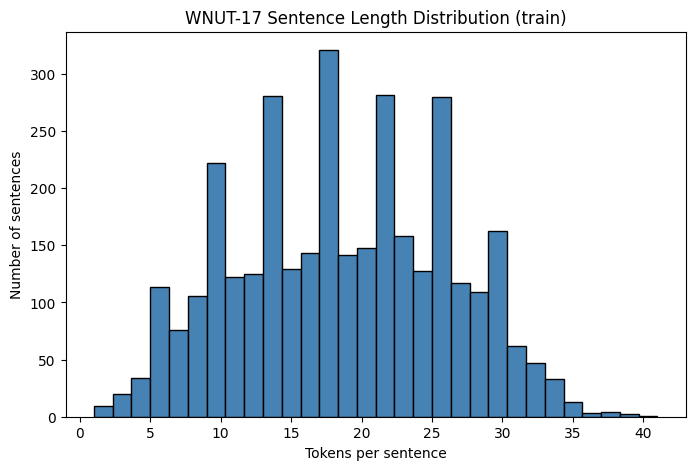

In [ ]:
all_tags_seen = set(t for s in wnut_train for w,t in s)
print("Unique NER tags:", sorted(all_tags_seen))

train_tokens = [w for s in wnut_train for w, t in s]
train_vocab = set(train_tokens)
print("Total tokens (train):", len(train_tokens))
print("Vocabulary size (train):", len(train_vocab))

sentence_lengths = [len(s) for s in wnut_train]
print("Min length:", min(sentence_lengths))
print("Max length:", max(sentence_lengths))
print("Avg length: %.2f" % (sum(sentence_lengths)/len(sentence_lengths)))

plt.figure(figsize=(8,5))
plt.hist(sentence_lengths, bins=30, color="steelblue", edgecolor="black")
plt.title("WNUT-17 Sentence Length Distribution (train)")
plt.xlabel("Tokens per sentence")
plt.ylabel("Number of sentences")
plt.show()


Entity type frequency:
O (non-entity) : 59570
person         : 995
location       : 793
group          : 414
creative-work  : 346
product        : 345
corporation    : 267


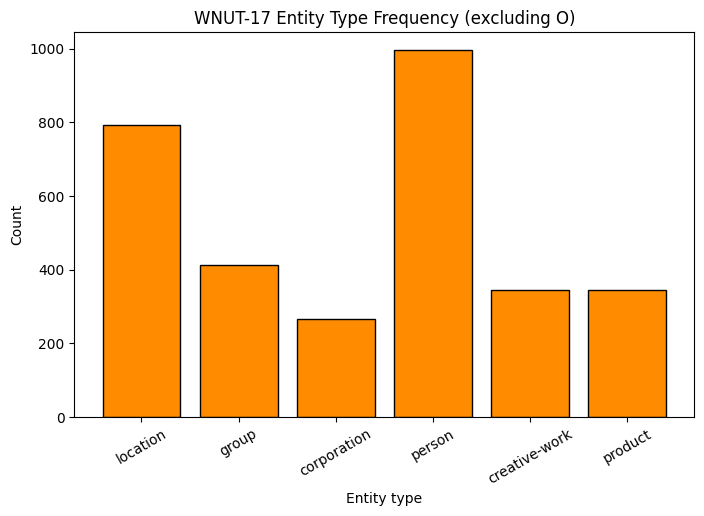

In [ ]:
tag_counter = Counter(t for s in wnut_train for w, t in s)
entity_type_counter = Counter()
for tag, count in tag_counter.items():
  if tag=="O":
    entity_type_counter["O (non-entity)"] += count
  else:
    entity_type_counter[tag.split("-", 1)[1]] += count

print("\nEntity type frequency:")
for etype, count in entity_type_counter.most_common():
    print(f"{etype:15s}: {count}")

plt.figure(figsize=(8,5))
types_no_o = {k:v for k,v in entity_type_counter.items() if k != "O (non-entity)"}
plt.bar(types_no_o.keys(), types_no_o.values(), color="darkorange", edgecolor="black")
plt.title("WNUT-17 Entity Type Frequency (excluding O)")
plt.xlabel("Entity type")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()



In [ ]:
X_train_wnut = [sentence_to_features(s) for s in wnut_train]
y_train_wnut = [[t for w, t in s] for s in wnut_train]

X_valid_wnut = [sentence_to_features(s) for s in wnut_valid]
y_valid_wnut = [[t for w, t in s] for s in wnut_valid]

X_test_wnut = [sentence_to_features(s) for s in wnut_test]
y_test_wnut = [[t for w, t in s] for s in wnut_test]

print(X_train_wnut[0][0])

{'word': '@paulwalk', 'word_lower': '@paulwalk', 'prefix_1': '@', 'prefix_2': '@p', 'prefix_3': '@pa', 'suffix_1': 'k', 'suffix_2': 'lk', 'suffix_3': 'alk', 'is_capitalized': False, 'is_all_caps': False, 'is_all_lower': True, 'is_numeric': False, 'has_hypen': False, 'word_length': 9, 'pos_tag': 'VB', 'BOS': True, 'next_word_lower': 'it', 'next_is_capitalized': True, 'next_pos_tag': 'PRP'}


In [ ]:
crf_wnut = sklearn_crfsuite.CRF(algorithm="lbfgs", c1 = 0.1, c2 = 0.1, max_iterations=100, all_possible_transitions=True)


crf_wnut.fit(X_train_wnut, y_train_wnut)

y_pred_wnut = crf_wnut.predict(X_test_wnut)

print("Precision:", precision_score(y_test_wnut, y_pred_wnut))
print("Recall:", recall_score(y_test_wnut, y_pred_wnut))
print("F1-score:", f1_score(y_test_wnut, y_pred_wnut))
print("\nEntity-wise performance:")
print(classification_report(y_test_wnut, y_pred_wnut))

Precision: 0.34011627906976744
Recall: 0.10843373493975904
F1-score: 0.16444132115249474

Entity-wise performance:
               precision    recall  f1-score   support

  corporation       0.00      0.00      0.00        66
creative-work       0.36      0.03      0.05       142
        group       0.20      0.04      0.06       165
     location       0.22      0.23      0.22       150
       person       0.54      0.17      0.26       429
      product       0.12      0.01      0.01       127

    micro avg       0.34      0.11      0.16      1079
    macro avg       0.24      0.08      0.10      1079
 weighted avg       0.34      0.11      0.15      1079



In [ ]:
# Confusion pairs
confusion_pairs = Counter()
missed, spurious, confusion = 0, 0, 0
for true_seq, pred_seq in zip(y_test_wnut, y_pred_wnut):
    for true_tag, pred_tag in zip(true_seq, pred_seq):
        if true_tag != pred_tag:
            confusion_pairs[(true_tag, pred_tag)] += 1
            if true_tag != "O" and pred_tag == "O":
              missed += 1
            elif true_tag == "O" and pred_tag != "O":
                spurious += 1
            else:
                confusion += 1

print("Most common confusions (true -> predicted):")
for (true_tag, pred_tag), count in confusion_pairs.most_common(15):
    print(f"  {true_tag:20s} -> {pred_tag:20s} : {count}")

print("\nMissed entities:", missed)
print("Spurious entities:", spurious)
print("Type confusion:", confusion)


idx = 50
display_sentence_predictions(wnut_test[idx], y_test_wnut[idx], y_pred_wnut[idx])

Most common confusions (true -> predicted):
  B-person             -> O                    : 310
  I-creative-work      -> O                    : 191
  B-group              -> O                    : 145
  B-creative-work      -> O                    : 114
  B-product            -> O                    : 110
  I-product            -> O                    : 110
  B-location           -> O                    : 90
  I-person             -> O                    : 80
  I-location           -> O                    : 72
  I-group              -> O                    : 62
  B-corporation        -> O                    : 56
  O                    -> B-location           : 54
  B-person             -> B-location           : 33
  O                    -> B-person             : 25
  O                    -> I-location           : 20

Missed entities: 1358
Spurious entities: 160
Type confusion: 178
WORD            TRUE       PRED       MATCH
---------------------------------------------
I             

## Discussion of Task 6

We repeated the full pipeline on **WNUT-17**, a dataset built specifically to test recognition of emerging and rare entities in informal social media text (Twitter, Reddit). Using the same CRF architecture and hand-crafted features, performance dropped sharply: F1 fell from `0.808` on **CoNLL-2003** to just `0.164` on **WNUT-17**, with precision `0.34` and recall only `0.11`. Entity-wise, person was the strongest category `(F1 0.26)`, while corporation scored `0.00`, every category scored far below its **CoNLL-2003** counterpart.

**The error breakdown explains why**: missed entities (1,358) vastly outnumbered spurious entities (160) and type confusion (178). This means the model's dominant failure mode on **WNUT-17** is failing to recognize entities at all, rather than mislabeling ones it does detect. This matches **WNUT-17**'s purpose, it specifically probes generalization to novel, previously-unseen entities in noisy, inconsistently-capitalized text, where the surface-level features that worked well on clean news text break down (e.g. "@paulwalk" or informally-cased words don't follow news-style conventions). A much smaller training set (3,394 sentences vs. 14,041) compounds the problem, leaving the CRF with far fewer reliable patterns to learn from.

This comparison directly reinforces the Task 5 conclusion: a production ticket-routing system dealing with informal customer language, much like **WNUT-17**'s social text, cannot rely on classical CRF surface features alone. It would need domain-specific fine-tuning data, contextual embeddings (e.g. a fine-tuned transformer model), or both, to reliably handle the kind of noisy, informal text real customers actually write.

## Submission Requirements
Submit one Jupyter Notebook (.ipynb) containing:
- Well-structured Markdown explanations
- Clearly commented code
- Visualizations where appropriate
- Results and discussion for each task